In [1]:
!pip install  torch torchvision pillow polars scikit-learn matplotlib pandas numpy seaborn tqdm

In [ ]:
import torch
import torch.nn as nn 
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder


from PIL import Image
import polars as pl
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import json
import random
import numpy as np

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'



preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])



### Load dữ liệu

In [ ]:

train_set = ImageFolder(root='./butterfly_dataset/train', transform=preprocess)
valid_set = ImageFolder(root='./butterfly_dataset/valid', transform=preprocess)
test_set = ImageFolder(root='./butterfly_dataset/test', transform=preprocess)

decoder = {i:x for i, x in enumerate(train_set.classes)}

with open('decode.json', 'w', encoding='utf-8') as f:
    json.dump(decoder, f, indent=4)

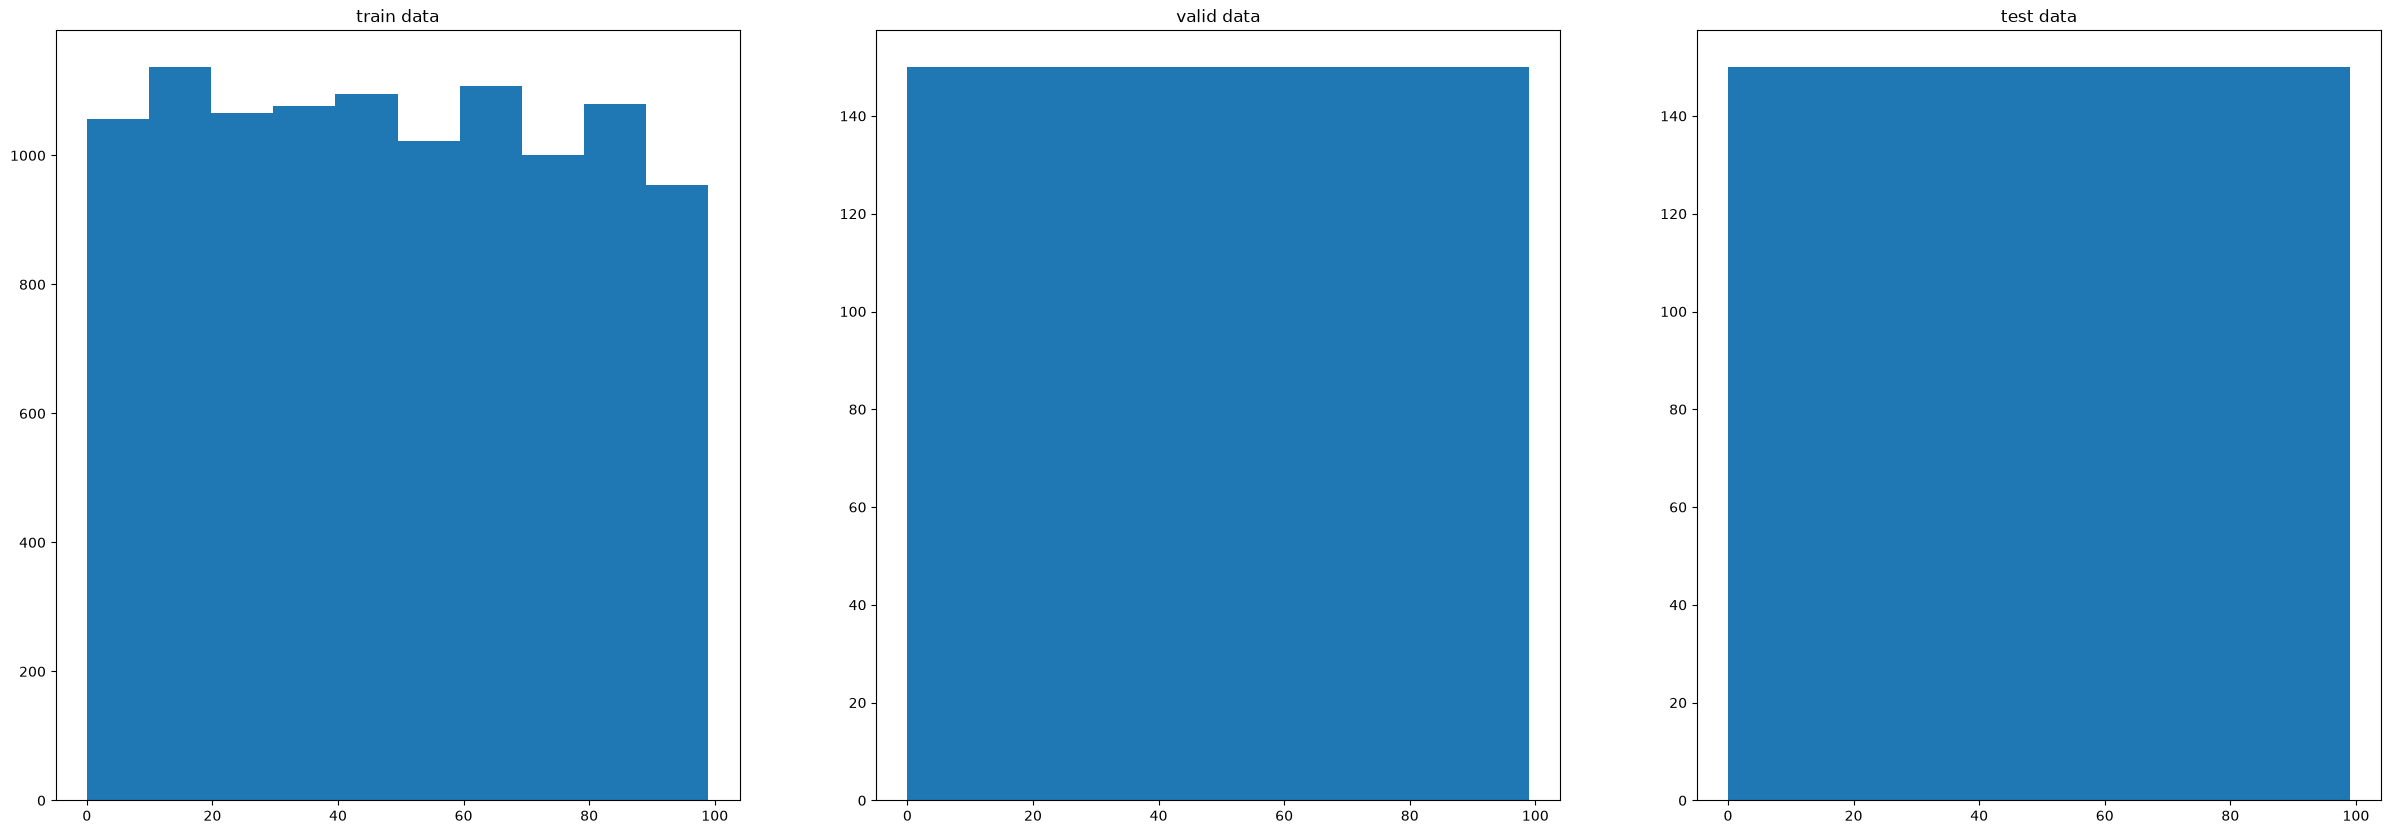

In [ ]:


data_history = {
    'train': [],
    'valid': [],
    'test': []
}

for X, y in train_set:
    data_history['train'].append(y)

for X, y in valid_set:
    data_history['valid'].append(y)

for X, y in test_set:
    data_history['test'].append(y)

_, axes = plt.subplots(1,3,figsize=(30,10))

for i, k in enumerate(data_history):
    axes[i].hist(data_history[k])
    axes[i].set_title(k + " data")

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)



### Training

In [ ]:
# Early stopping
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):

        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss



# Hàm train
def train(checkpoint_name, model, train_loader, valid_loader, device, epochs, lr):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    early_stopping = EarlyStopping(patience=5, verbose=True, path=checkpoint_name, delta=0.001)

    history = {
        'train_loss': [],
        'val_loss': [],
        'acc': []
    }



    best_val_loss = float('inf')

    for epoch in range(epochs):
        train_loss = 0

        model.train()

        for bX, by in train_loader:
            bX = bX.to(device)
            by = by.to(device)

            optimizer.zero_grad()

            by_pred = model(bX)

            loss = criterion(by_pred, by)

            train_loss += loss.item()
            loss.backward()
            optimizer.step()
        

        avg_train_loss = train_loss / len(train_loader)

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for bX, by in valid_loader:
                bX, by = bX.to(device), by.to(device)

                by_pred= model(bX)

                loss = criterion(by_pred, by)

                _, predict = torch.max(by_pred, 1)

                val_loss += loss.item()

                total += by_pred.size(0)
                correct += (predict == by).sum().item()

        
        avg_val_loss = val_loss / len(valid_loader)
        acc = 100 * correct / total
        

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['acc'].append(acc)
        print(f"Epoch: {epoch+1}/{epochs}: ")

        print(f"--Training Loss: {avg_train_loss}\n--Validation Loss: {avg_val_loss}\n--Accuracy: {acc:.4f}")

        ### early stopping

        early_stopping(avg_val_loss, model)
    
        if early_stopping.early_stop:
            print("Training stop!")
            break


    return history



    

In [ ]:

def plot_results(history, name):
    epochs = range(1, len(history['train_loss']) + 1)

    # plt.figure(figsize=(12, 5))

    # plot train & eval
    # plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Eval Loss')
    plt.title('Training and Evaluation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # # plot accuracy
    # plt.subplot(1, 2, 2)
    # plt.plot(epochs, history['acc'], 'g-', label='Eval Accuracy')
    # plt.title('Evaluation Accuracy')
    # plt.xlabel('Epochs')
    # plt.ylabel('Accuracy (%)')
    # plt.legend()

    plt.title(name)

    plt.tight_layout()
    plt.show()




In [ ]:
class BilinearVGG16(nn.Module):
    def __init__(self, num_classes):
        super(BilinearVGG16, self).__init__()
        
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)


        self.features = vgg.features
    
        for param in self.features.parameters():
            param.requires_grad = False

        self.classifier = nn.Linear(512 * 512, num_classes)
        
    def forward(self, x):

        x = self.features(x)
        
        batch_size, channels, height, width = x.size()
        
        x = x.view(batch_size, channels, height * width)
        
        # Outer product ([B, C, H*W] * [B, H*W, C] -> [B, C, C])
        bilinear_matrix = torch.bmm(x, x.transpose(1, 2))
        
        # Flatten [B, C * C]
        v = bilinear_matrix.view(batch_size, channels * channels)
        
        # Element-wise square root
        v = torch.sign(v) * torch.sqrt(torch.abs(v) + 1e-12)
        
        # L2 Norm
        v = nn.functional.normalize(v, p=2, dim=1)
        
        out = self.classifier(v)
        return out


In [ ]:
import seaborn as sns
def show_report(model, device, loader, name_classes):
    model.eval()

    preds = []
    gt = []

    with torch.no_grad():
        for bX, by in loader:
            bX = bX.to(device)
            by = by.to(device)

            by_pred = model(bX)

            _, pred = torch.max(by_pred, dim=1)

            preds.extend(pred.cpu().numpy())
            gt.extend(by.cpu().numpy())
    
    report = classification_report(gt, preds, target_names=name_classes, digits=5)

    return report


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm  

def evaluate_and_plot_worst_cm(model, test_loader, device, class_names, top_k=10, save_path=None, cmap='OrRd'):

    
    model.to(device)
    model.eval() 
    
    all_preds = []
    all_labels = []
    
    print("\n[INFO] Bắt đầu chạy suy luận trên tập dữ liệu...")
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("[INFO] Quá trình suy luận hoàn tất. Đang tính toán Metrics...")
    
    y_true_names = [class_names[i] for i in all_labels]
    y_pred_names = [class_names[i] for i in all_preds]
    
    report = classification_report(y_true_names, y_pred_names, labels=class_names, output_dict=True, zero_division=0)
    class_metrics = {k: v for k, v in report.items() if k in class_names}
    
    worst_classes_info = sorted(class_metrics.items(), key=lambda x: x[1]['f1-score'])[:top_k]
    worst_k_names = [item[0] for item in worst_classes_info]
    
    print(f"\n--- Top {top_k} loài có F1-score thấp nhất ---")
    for i, (name, metrics) in enumerate(worst_classes_info):
        print(f"{i+1}. {name}: F1-score = {metrics['f1-score']:.4f}")
    
    cm = confusion_matrix(y_true_names, y_pred_names, labels=worst_k_names)
    
    plt.figure(figsize=(10 + top_k*0.2, 8 + top_k*0.2))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                     xticklabels=worst_k_names, yticklabels=worst_k_names,
                     linewidths=1, linecolor='gray',
                     annot_kws={"size": 11, "weight": "bold"})
    
    plt.title(f'Confusion Matrix', fontsize=16, pad=20, fontweight='bold')
    plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=14, labelpad=15, fontweight='bold')
    plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=14, labelpad=15, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    
    # 7. Lưu kết quả
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n[+] Đã lưu biểu đồ sắc nét tại: {save_path}")
    else:
        plt.show()

In [ ]:
# vgg16_finetune = VGG16_Finetune(100)
vgg16_bilinear = BilinearVGG16(100)
# vgg16_bilinear.load_state_dict(torch.load("vgg16_bilinear_lr_0.0005.pt", map_location=device))

In [ ]:
checkpoint_name = "vgg16_bilinear"
vgg16_bilinear.to(device)

BilinearVGG16(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, 

In [ ]:
history = train(checkpoint_name, vgg16_bilinear, train_loader, valid_loader, device, 100, 5e-4)
plot_results(history, "VGG16 Bilinear")


Epoch: 1/100: 
--Training Loss: 4.285177081464285
--Validation Loss: 3.982065657774607
--Accuracy: 51.0000
Validation loss decreased (inf --> 3.982066). Saving model...
Epoch: 2/100: 
--Training Loss: 3.6741341826427414
--Validation Loss: 3.432709922393163
--Accuracy: 69.8667
Validation loss decreased (3.982066 --> 3.432710). Saving model...
Epoch: 3/100: 
--Training Loss: 3.1461977140012993
--Validation Loss: 2.962972730398178
--Accuracy: 76.1333
Validation loss decreased (3.432710 --> 2.962973). Saving model...
Epoch: 4/100: 
--Training Loss: 2.697541295763958
--Validation Loss: 2.5644971827665963
--Accuracy: 79.6000
Validation loss decreased (2.962973 --> 2.564497). Saving model...
Epoch: 5/100: 
--Training Loss: 2.320898814373706
--Validation Loss: 2.2350419213374457
--Accuracy: 82.5333
Validation loss decreased (2.564497 --> 2.235042). Saving model...
Epoch: 6/100: 
--Training Loss: 2.0108849880207016
--Validation Loss: 1.9642685651779175
--Accuracy: 83.6000
Validation loss decrea

In [ ]:

report = show_report(vgg16_bilinear, device, valid_loader, train_set.classes)

print(report)

                           precision    recall  f1-score   support

                   ADONIS      0.706     0.800     0.750        15
AFRICAN GIANT SWALLOWTAIL      1.000     0.933     0.966        15
           AMERICAN SNOOT      1.000     0.933     0.966        15
                    AN 88      1.000     1.000     1.000        15
                  APPOLLO      0.933     0.933     0.933        15
     ARCIGERA FLOWER MOTH      0.938     1.000     0.968        15
                    ATALA      1.000     1.000     1.000        15
               ATLAS MOTH      0.933     0.933     0.933        15
 BANDED ORANGE HELICONIAN      0.938     1.000     0.968        15
           BANDED PEACOCK      1.000     1.000     1.000        15
        BANDED TIGER MOTH      0.923     0.800     0.857        15
            BECKERS WHITE      0.933     0.933     0.933        15
  BIRD CHERRY ERMINE MOTH      1.000     0.933     0.966        15
         BLACK HAIRSTREAK      1.000     0.933     0.966     


[INFO] Bắt đầu chạy suy luận trên tập dữ liệu...


Evaluating: 100%|██████████| 24/24 [00:12<00:00,  1.90it/s]


[INFO] Quá trình suy luận hoàn tất. Đang tính toán Metrics...

--- Top 10 loài có F1-score thấp nhất ---
1. PURPLE HAIRSTREAK: F1-score = 0.5161
2. PURPLISH COPPER: F1-score = 0.6087
3. COPPER TAIL: F1-score = 0.6486
4. DANAID EGGFLY: F1-score = 0.6667
5. ADONIS: F1-score = 0.7027
6. GREY HAIRSTREAK: F1-score = 0.7143
7. SOOTYWING: F1-score = 0.7143
8. BLACK HAIRSTREAK: F1-score = 0.7200
9. CRECENT: F1-score = 0.7586
10. SOUTHERN DOGFACE: F1-score = 0.7586


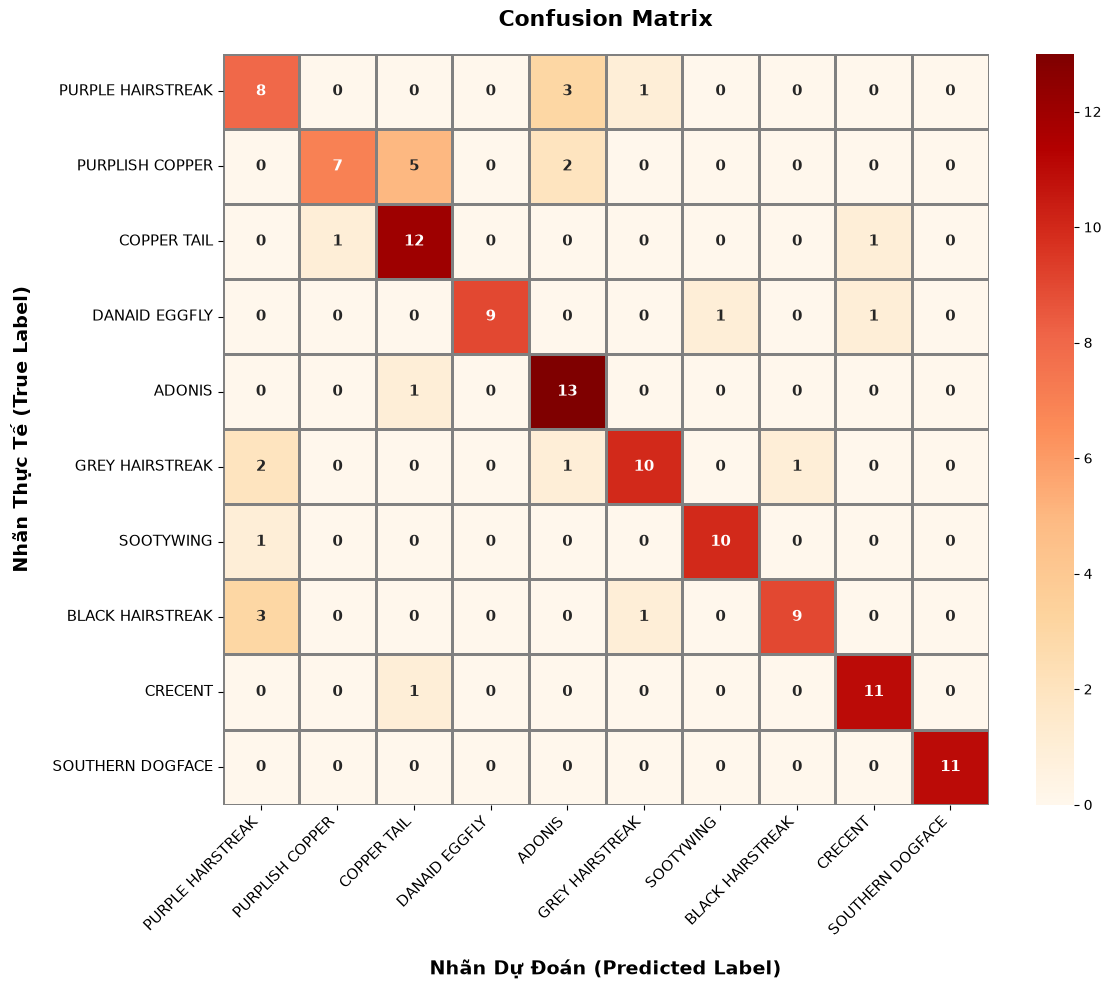

In [ ]:
evaluate_and_plot_worst_cm(vgg16_bilinear, test_loader, device, test_set.classes, 10)

In [ ]:
print(show_report(vgg16_bilinear, device, test_loader, test_set.classes))

                           precision    recall  f1-score   support

                   ADONIS      0.591     0.867     0.703        15
AFRICAN GIANT SWALLOWTAIL      1.000     0.933     0.966        15
           AMERICAN SNOOT      1.000     0.933     0.966        15
                    AN 88      1.000     1.000     1.000        15
                  APPOLLO      1.000     0.933     0.966        15
     ARCIGERA FLOWER MOTH      0.938     1.000     0.968        15
                    ATALA      1.000     1.000     1.000        15
               ATLAS MOTH      1.000     1.000     1.000        15
 BANDED ORANGE HELICONIAN      1.000     0.867     0.929        15
           BANDED PEACOCK      1.000     1.000     1.000        15
        BANDED TIGER MOTH      1.000     0.867     0.929        15
            BECKERS WHITE      1.000     0.867     0.929        15
  BIRD CHERRY ERMINE MOTH      1.000     1.000     1.000        15
         BLACK HAIRSTREAK      0.900     0.600     0.720     

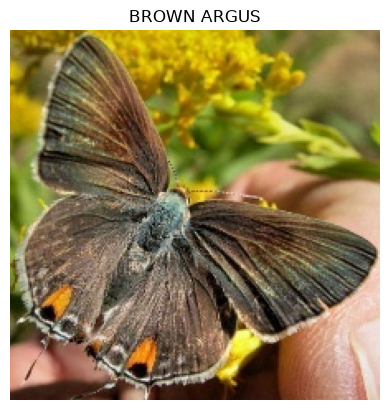

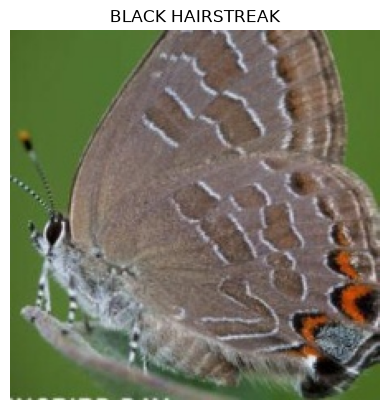

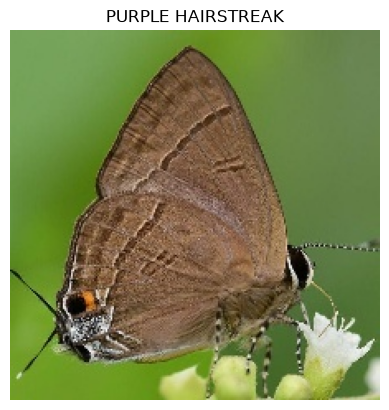

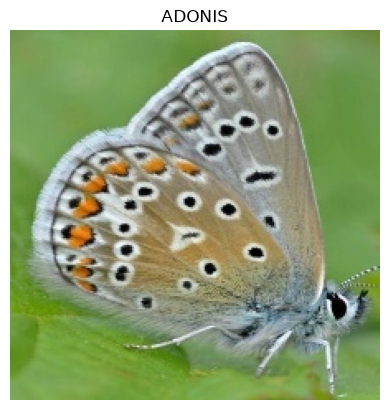

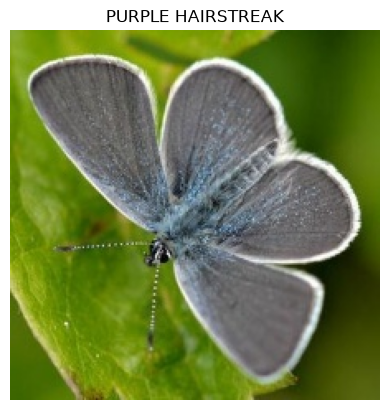

In [ ]:
cwd = os.getcwd()
cl = 'GREY HAIRSTREAK'
p = 'butterfly_dataset/test/' + cl

for i, item in enumerate(os.listdir(os.path.join(cwd, p))):
    img = Image.open(p + '/' + item)

    img_tensor = preprocess(img).unsqueeze(0)
    img_tensor = img_tensor.to('cuda')
    output = vgg16_bilinear(img_tensor)

    _, idx = torch.max(output, dim=1)

    idx = idx.item()
    class_name = test_set.classes[idx]
    if class_name != cl:
        plt.title(test_set.classes[idx])
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
        

    

In [ ]:
def show_val_loss(model, device, loader):
    model.to(device)
    model.eval()

    with torch.no_grad():
        criterion = nn.CrossEntropyLoss()
        total_loss = 0
        for bX, by in loader:
            bX, by = bX.to(device), by.to(device)

            by_pred = model(bX)

            loss = criterion(by_pred, by)

            total_loss += loss.item()
        
        return total_loss / len(loader)




        


In [ ]:
print(show_val_loss(vgg16_bilinear, device, valid_loader))

0.2802000188579162
